In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid')
np.random.seed(42)
print('setup complete')

setup complete


# 1. Data Loading & Exploration
we start with the classic `Iris` dataset (flower measurements) to practise exploration. Always look at your data before modelling


In [32]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame             # a pandas DataFrame
df['species'] = iris.target_names[iris.target]
print('Shape:', df.shape)
df.head()

Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [33]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


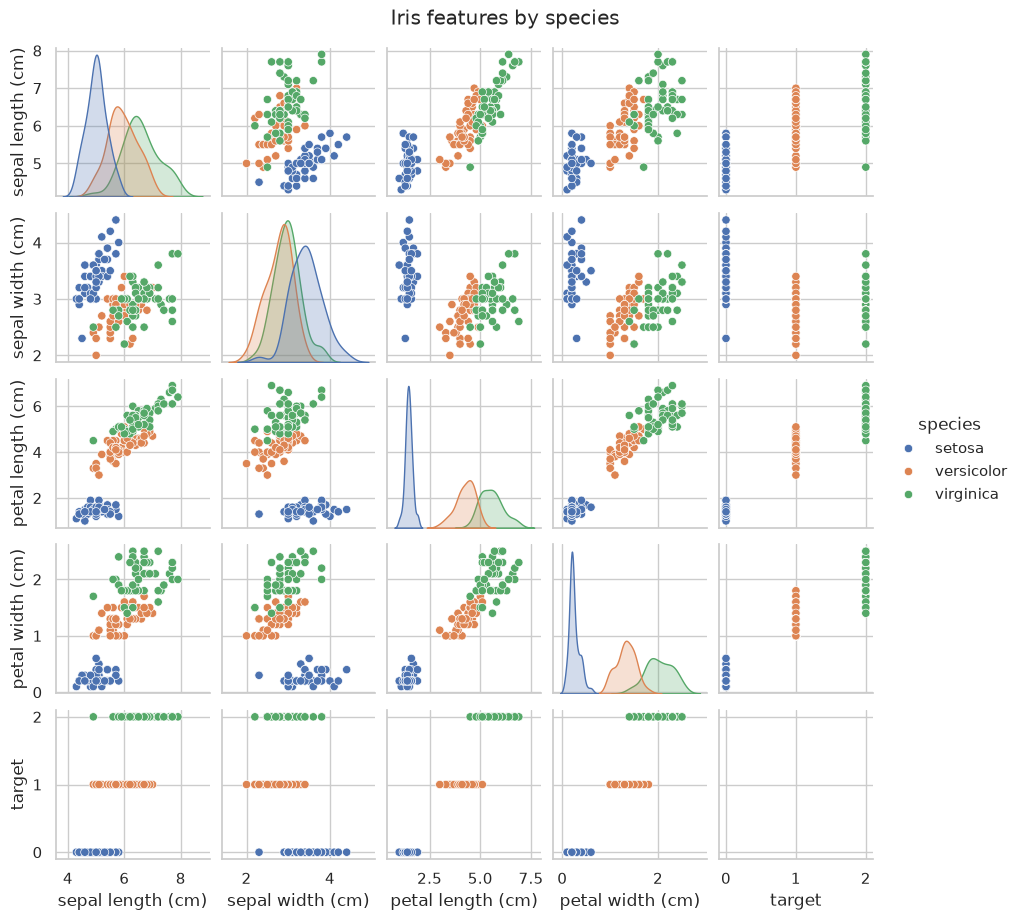

In [34]:
# How many of each species?
print(df['species'].value_counts())

# Visualize relationships between features
sns.pairplot(df, hue='species', height=1.8)
plt.suptitle('Iris features by species', y=1.02)
plt.show()

# 2. Data Preprocessing
Real data needs cleaning. We demonstrate the four key steps: `missing values`, `encoding`, `scaling`, and the `train test split`

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# missing values (demo) : create one, then fill it with the column mean
demo = df.copy()
demo.loc[0, 'sepal length (cm)'] = 0
print('Missing before: ', demo.isnull().sum().sum())
demo['sepal length (cm)'] = demo['sepal length (cm)'].fillna(demo['sepal length (cm)'].mean())
print("Missing after: ", demo.isnull().sum().sum())

# encoding: turn text labels into numbers
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(df['species'])
x = df.drop(columns=['species', 'target'])

# train test split (80/20)
xTrain, xTest, yTrain, yTest = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
    )

# scaling: bring all feature to a similar range
scaler = StandardScaler()
xTrainS = scaler.fit_transform(xTrain)
xTestS = scaler.fit_transform(xTest)

print('Train size: ', xTrain.shape, 'Test size: ', xTest.shape)

Missing before:  0
Missing after:  0
Train size:  (120, 4) Test size:  (30, 4)


# 3. Regression - Salary Prediction
`Regression predicts a number`. We build a realistic synthetic salary dataset (experience, test score, interview score -> salary) and compare three modles.

In [36]:
# Build a synthetic but realistic salary dataset

n = 300
experience = np.random.randint(0, 20, n)
testScore = np.random.randint(40, 100, n)
interview = np.random.randint(1, 10, n)
salary = (25000
          + experience * 2500
          + testScore * 300
          + interview * 1500
          + np.random.normal(0, 4000, n))   # noise
dfSalary = pd.DataFrame({
    'experience' : experience,
    'testScore' : testScore,
    'interviewScore' : interview,
    'salary' : salary.round(0)
})

dfSalary

,experience,testScore,interviewScore,salary
0,6,64,4,67313.0
1,19,81,5,105130.0
2,14,70,4,95173.0
3,10,93,5,91878.0
4,7,97,7,85832.0
...,...,...,...,...
295,0,92,6,57396.0
296,19,44,6,86965.0
297,0,74,1,43870.0
298,2,51,8,53018.0


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, r2_score

xR = dfSalary[['experience', 'testScore', 'interviewScore']]
yR = dfSalary['salary']

xRTrain, xRTest, yRTrain, yRTest = train_test_split(xR, yR, test_size=0.2, random_state=42)

models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(xRTrain, yRTrain)
    pred = model.predict(xRTest)


/home/zeus/programming/python/.venv/lib64/python3.14/site-packages/sklearn/ensemble/_forest.py:811: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/zeus/programming/python/.venv/lib64/python3.14/site-packages/sklearn/tree/_classes.py:289: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/zeus/programming/python/.venv/lib64/python3.14/site-packages/sklearn/tree/_classes.py:289: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/zeus/programming/python/.venv/lib64/python3.14/site-packages/sklearn/tree/_classes.py:289: UserWarning: The number of 

In [38]:
for name, modle in models.items():
    print(f"{name:18}, MAE = {mean_absolute_error(yRTest, pred):8.0f} R2 = {r2_score(yRTest, pred)}")

Linear Regression , MAE =     8279 R2 = 0.5600642462438988
Random Forest     , MAE =     8279 R2 = 0.5600642462438988
Gradient Boosting , MAE =     8279 R2 = 0.5600642462438988


In [ ]:
LogisticRegression# Predict salary for a new candidate : 5 years experience, score 80, interview 7

best = models['Gradient Boosting']
newCandidate = [[5, 80, 7]]
print('Predicted Salary: ', round(best.predict(newCandidate)[0],0))

Predicted Salary:  71692.0


/home/zeus/programming/python/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


# 4. Classification - Medical Diagnosis

`classification` predicts a category. we use the Breast cancer dataset (malignant vs benign) and compare four classic algorithms

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()
xC, yC = cancer.data, cancer.target       # target: 0 = malignant, 1 = benign

xCTrain, xCTest, yCTrain, yCTest = train_test_split(
    xC, yC, test_size=0.2, random_state=42, stratify=yC
)


# scale (important for Logistic Regression and KNN)
sc = StandardScaler()
xCTrainScale = sc.fit_transform(xCTrain)
xCTestScale = sc.transform(xCTest)

classifiers = {
    'Logistic Regression' : LogisticRegression(max_iter=5000),
    'KNN' : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree' : DecisionTreeClassifier(random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, clf in classifiers.items():
    clf.fit(xCTrain, yCTrain)
    acc = clf.score(xCTest, yCTest)
    print(f"{name:22} accuracy = {acc:.3f}")

Logistic Regression    accuracy = 0.965
KNN                    accuracy = 0.912
Decision Tree          accuracy = 0.930
Random Forest          accuracy = 0.956


# Model Evaluation - beyond accuraccy

Accuracy alone can mislead. We look at `precision, recall, F1`, the `confusion matrix`, and the `ROC-AUC` for our classifier

In [44]:
from sklearn.metrics import(classification_report, confusion_matrix, roc_auc_score, roc_curve)

clf = classifiers['Random Forest']
yPred = clf.predict(xCTest)
yProba = clf.predict_proba(xCTest)[:,1]

print(classification_report(yCTest, yPred, target_names=cancer.target_names))
print('ROC_AUC:', round(roc_auc_score(yCTest, yProba),3))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC_AUC: 0.992


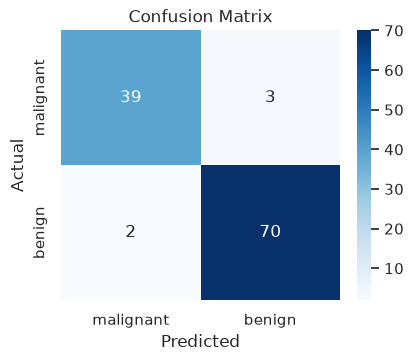

In [51]:
# confusion matrix as a heatmap
cm = confusion_matrix(yCTest, yPred)
plt.figure(figsize = (4.5, 3.5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

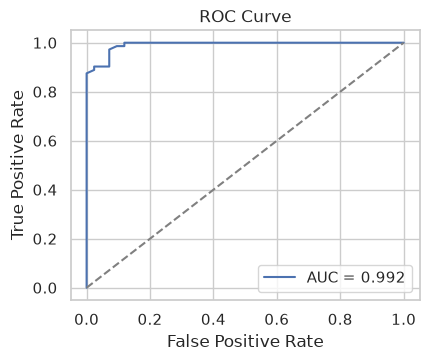

In [53]:
# ROC curve
fpr, tpr, _ = roc_curve(yCTest, yProba)
plt.figure(figsize=(4.5, 3.5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(yCTest, yProba):.3f}')
plt.plot([0,1], [0,1], '--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")
plt.legend()
plt.show()


# 6. Ensemble Methods 

**Emsembles combinemany models for better accuracy**. We compare baggin and boosting.

In [54]:
from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier)
from sklearn.model_selection import cross_val_score

ensembles = {
    'Bagging' : BaggingClassifier(n_estimators=50, random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost' : AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=42)
}

for name, model in ensembles.items():
    scores = cross_val_score(model, xCTrain, yCTrain, cv=5)
    print(f"{name:18} CV accuracy = {scores.mean():.3f} (+/- {scores.std():.3f})")

Bagging            CV accuracy = 0.954 (+/- 0.019)
Random Forest      CV accuracy = 0.954 (+/- 0.023)
AdaBoost           CV accuracy = 0.974 (+/- 0.022)
Gradient Boosting  CV accuracy = 0.956 (+/- 0.014)


# 7. Hyperparameter Tuning

**Grid Search** tries many settings with **cross-validation** and keeps the best combo.

In [ ]:
from sklearn.model_selection import GridSearchCV   # CV stands for cross validation

param_grid = {
    'n_estimators' : [50,100,200],
    'max_depth' : [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,cv=5, n_jobs=-1)
grid.fit(xCTrainScale, yCTrain)

print('Best settings: ', grid.best_params_)
print('Best CV score: ', round(grid.best_score_,3))
print('Test accuracy: ', round(grid.score(xCTestScale, yCTest), 3))



Best settings:  {'max_depth': None, 'n_estimators': 200}
Best CV score:  0.96
Test accuracy:  0.956


# 8. Unsupervised Learning - Customer Segmentation 
**Clustering groups data without labels.** We create customers (income vs spending) and group them with `K-Mean`, then compare with `hierarchical clustering`.

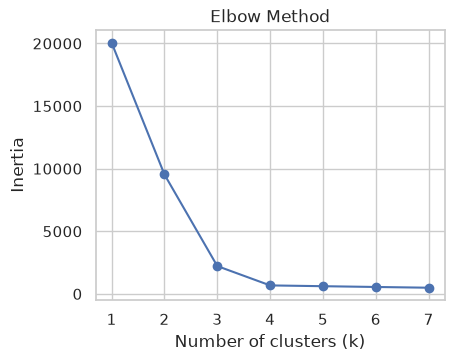

In [57]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# synthetic customers: annual income vs spending score
xCust, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.1, random_state=42)

# Elbow method: find a good number of clusters
inertia = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(xCust)
    inertia.append(km.inertia_)

plt.figure(figsize=(4.5,3.5))
plt.plot(range(1,8), inertia, 'o-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()


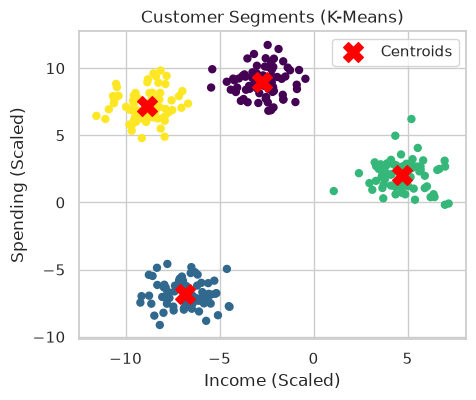

In [66]:
# Fit K-Means with k-4 and plot the segments

km = KMeans(n_clusters=4, n_init=10, random_state=42)
labels = km.fit_predict(xCust)

plt.figure(figsize=(5, 4))
plt.scatter(xCust[:,0], xCust[:,1], c=labels, cmap='viridis', s=25)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], c='red', marker='X', s=200, label = 'Centroids')
plt.xlabel('Income (Scaled)')
plt.ylabel('Spending (Scaled)')
plt.title('Customer Segments (K-Means)')
plt.legend()
plt.show()

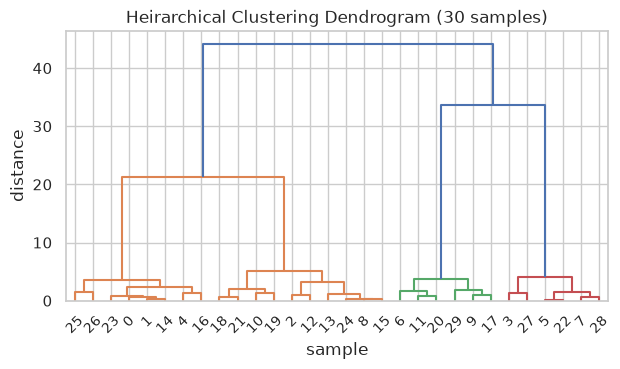

Heirarchical clusters found: 4


In [68]:
# Heirarchical Clustering: denrogram + Agglomerative Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

linked = linkage(xCust[:30], method = 'ward') # small sample for a clear tree
plt.figure(figsize=(7, 3.5))
dendrogram(linked)
plt.title('Heirarchical Clustering Dendrogram (30 samples)')
plt.xlabel('sample')
plt.ylabel('distance')
plt.show()

agg = AgglomerativeClustering(n_clusters=4)
aggLabels = agg.fit_predict(xCust)
print('Heirarchical clusters found:', len(np.unique(aggLabels)))

# 9. Dimensionality Reducation - PCA

**PCA** squeezes many columns into a few while keeping most information - **great for visualising high dimensional data**. We reduce the 30 feautre cancer dat to 2D

Variance explained by 2 components: [0.443 0.19 ] Total: 0.632


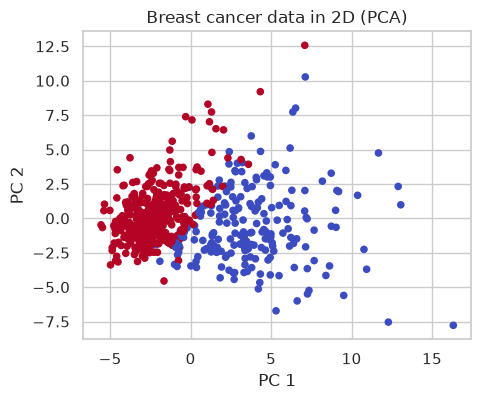

In [70]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
xPCA = pca.fit_transform(StandardScaler().fit_transform(xC))

print('Variance explained by 2 components:',
        np.round(pca.explained_variance_ratio_,3),
        'Total:', round(pca.explained_variance_ratio_.sum(),3))

plt.figure(figsize=(5,4))
plt.scatter(xPCA[:,0], xPCA[:,1], c=yC, cmap = 'coolwarm', s=20)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Breast cancer data in 2D (PCA)')
plt.show()

# 10. NLP spam/fake news style text Classification
Turn text into number with tf-idf, then classify with naive